In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

In [3]:
df = pd.read_csv("sample_load_data.csv", parse_dates=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)
print(f"✅ Loaded {len(df)} rows")
print(df.head())

✅ Loaded 8760 rows
             datetime  load_kw
0 2023-01-01 00:00:00    100.0
1 2023-01-01 01:00:00    100.0
2 2023-01-01 02:00:00    100.0
3 2023-01-01 03:00:00    108.2
4 2023-01-01 04:00:00    100.0


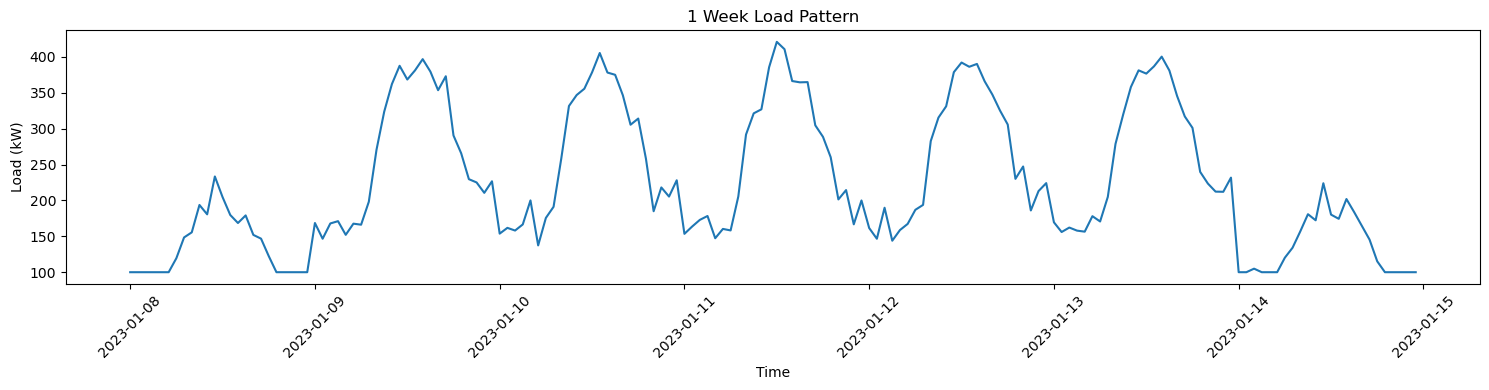

In [7]:
import matplotlib.pyplot as plt

# 1 hafte ka data plot karo
one_week = df.iloc[:168]

plt.figure(figsize=(15, 4))
plt.plot(one_week["datetime"], one_week["load_kw"])
plt.title("1 Week Load Pattern")
plt.xlabel("Time")
plt.ylabel("Load (kW)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

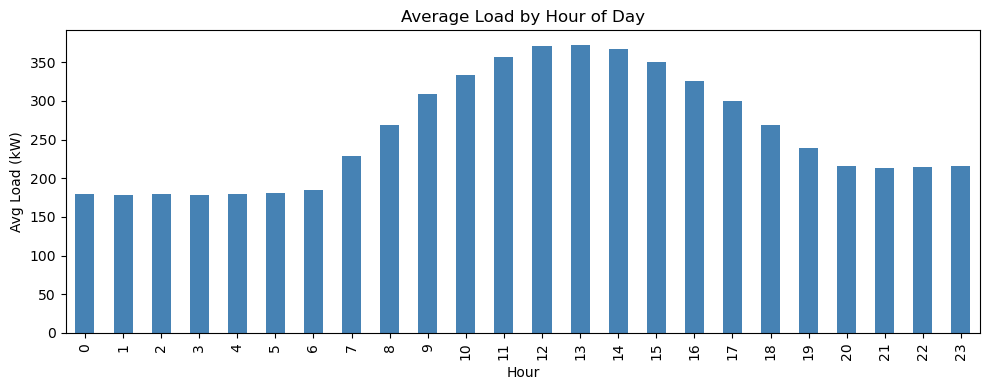

In [9]:
plt.figure(figsize=(10, 4))
df.groupby("hour")["load_kw"].mean().plot(kind="bar", color="steelblue")
plt.title("Average Load by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Avg Load (kW)")
plt.tight_layout()
plt.show()

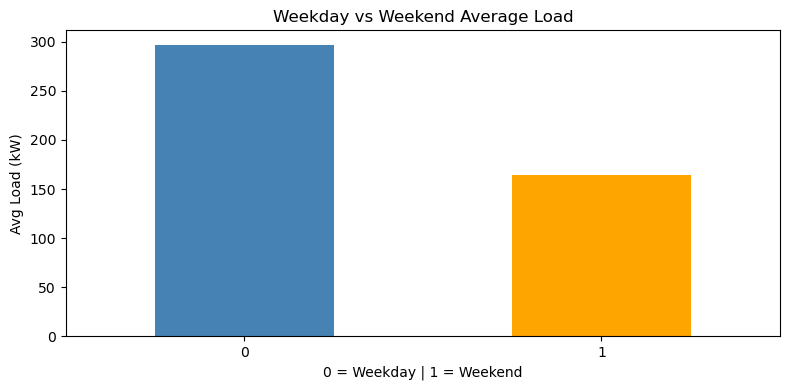

In [11]:
plt.figure(figsize=(8, 4))
df.groupby("is_weekend")["load_kw"].mean().plot(kind="bar", color=["steelblue", "orange"])
plt.title("Weekday vs Weekend Average Load")
plt.xlabel("0 = Weekday | 1 = Weekend")
plt.ylabel("Avg Load (kW)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
df["hour"]        = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek
df["month"]       = df["datetime"].dt.month
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)
df["day_of_year"] = df["datetime"].dt.dayofyear

df["lag_1h"]      = df["load_kw"].shift(1)
df["lag_24h"]     = df["load_kw"].shift(24)
df["lag_168h"]    = df["load_kw"].shift(168)

df["rolling_3h"]  = df["load_kw"].shift(1).rolling(3).mean()
df["rolling_24h"] = df["load_kw"].shift(1).rolling(24).mean()

df = df.dropna().reset_index(drop=True)
print(f"✅ Features ready: {len(df)} rows")
print(df.head())

✅ Features ready: 8592 rows
             datetime  load_kw  hour  day_of_week  month  is_weekend  \
0 2023-01-08 00:00:00    100.0     0            6      1           1   
1 2023-01-08 01:00:00    100.0     1            6      1           1   
2 2023-01-08 02:00:00    100.0     2            6      1           1   
3 2023-01-08 03:00:00    100.0     3            6      1           1   
4 2023-01-08 04:00:00    100.0     4            6      1           1   

   day_of_year  lag_1h  lag_24h  lag_168h  rolling_3h  rolling_24h  
0            8  113.81    100.0     100.0  104.603333   135.779583  
1            8  100.00    100.0     100.0  104.603333   135.779583  
2            8  100.00    100.0     100.0  104.603333   135.779583  
3            8  100.00    100.0     108.2  100.000000   135.779583  
4            8  100.00    100.0     100.0  100.000000   135.779583  


In [13]:
FEATURES = [
    "hour", "day_of_week", "month", "is_weekend", "day_of_year",
    "lag_1h", "lag_24h", "lag_168h",
    "rolling_3h", "rolling_24h"
]
TARGET = "load_kw"

X = df[FEATURES]
y = df[TARGET]

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"✅ Train: {len(X_train)} rows")
print(f"✅ Test : {len(X_test)} rows")

✅ Train: 6873 rows
✅ Test : 1719 rows


In [15]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
print("✅ Model trained!")

✅ Model trained!


In [17]:
preds = model.predict(X_test)

mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mape = np.mean(np.abs((y_test - preds) / y_test)) * 100

print(f"📊 Model Performance:")
print(f"   MAE  : {mae:.2f} kW")
print(f"   RMSE : {rmse:.2f} kW")
print(f"   MAPE : {mape:.2f}%")

📊 Model Performance:
   MAE  : 15.44 kW
   RMSE : 19.44 kW
   MAPE : 8.09%


In [19]:
joblib.dump(model, "load_prediction_model.pkl")
joblib.dump(FEATURES, "model_features.pkl")
print("✅ Model saved: load_prediction_model.pkl")
print("✅ Features saved: model_features.pkl")

✅ Model saved: load_prediction_model.pkl
✅ Features saved: model_features.pkl
